# ERA5 Pretrained — flash-aurora Engine

与官方 [`aurora/docs/example_era5.ipynb`](aurora/docs/example_era5.ipynb) 相同的数据与预报设置（2023-01-01，2 步 rollout → 12:00 / 18:00），但使用 **flash-aurora Engine** 的 `DataDownloader` 下载数据并推理。

## 前置条件

1. **Kernel**：`Python (flash-aurora)`，工作目录为 `flash-aurora/`。
2. **CDS 凭证**（任选）：环境变量 `CDSAPI_KEY`、`~/.cdsapirc`、或 notebook 里 `getpass` 输入。
3. 安装下载依赖：`uv pip install cdsapi netcdf4`。
4. **权重**：在 setup cell 指定 `ASSET_ROOT`；本地无 ckpt 时可 `allow_hub_download=True`，并用 `hf_mirror=True` 或 `hf_endpoint=` 从 Hugging Face / 镜像站拉取。
5. 需要 GPU 运行 0.25° 全球推理。
6. **网络**：CDS 只有官方 API；HF 国内常用镜像 `https://hf-mirror.com`（通过 API 设置，无需 export）。


In [1]:
from datetime import datetime
from pathlib import Path

from engine.bootstrap import ensure_repo_paths

ensure_repo_paths()

from engine import DataDownloader, HF_MIRROR_ENDPOINT, normalize_asset_path
from engine.core.presets import DEFAULT_PRESETS
from engine.core.redaction import safe_path

PRESET = "era5_pretrained"
DAY = "2023-01-01"
VALID_TIME = datetime(2023, 1, 1, 6)
ROLLOUT_STEPS = 2

# 资源目录（下载的 ERA5、HF 权重、static pickle 都落在这里）
ASSET_ROOT = normalize_asset_path("/root/autodl-tmp/aurora")

variant = DEFAULT_PRESETS.get(PRESET).variant
CHECKPOINT_PATH = normalize_asset_path(ASSET_ROOT / variant.checkpoint_filename)
HAS_LOCAL_CKPT = CHECKPOINT_PATH.is_file()

# 本地无权重时从 Hub 拉取；国内可 hf_mirror=True 或 hf_endpoint=HF_MIRROR_ENDPOINT
ALLOW_HUB_DOWNLOAD = not HAS_LOCAL_CKPT
USE_HF_MIRROR = False  # 国内连不上 huggingface.co 时改为 True
HF_ENDPOINT = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
cache_dir = downloader.resolve_cache_dir()

print("cache_dir:", safe_path(cache_dir))
print("asset_root:", safe_path(ASSET_ROOT))
print("checkpoint:", safe_path(CHECKPOINT_PATH), HAS_LOCAL_CKPT)
print("allow_hub_download:", ALLOW_HUB_DOWNLOAD)
print("hf_endpoint:", HF_ENDPOINT or "https://huggingface.co (default)")


cache_dir: ~/autodl-tmp/aurora/era5
asset_root: ~/autodl-tmp/aurora
checkpoint: ~/autodl-tmp/aurora/aurora-0.25-pretrained.ckpt True
allow_hub_download: False
hf_endpoint: https://huggingface.co (default)


## 1. 下载 ERA5 数据（CDS 官方 API）

与官方 notebook 完全相同的三个 NetCDF 文件。已存在则跳过下载。


In [2]:
import getpass
import os
from pathlib import Path

from engine.core.redaction import safe_path

# CDS 凭证（任选其一，优先级从上到下）：
# 1) 环境变量：export CDSAPI_KEY=你的-key
# 2) 直接赋值（本地测试；勿把 key 写进 notebook 并提交 git）
# 3) getpass 交互输入 —— 括号里只是提示语，不是你的 key！要在隐藏输入框里粘贴 key
CDS_API_KEY = os.environ.get("CDSAPI_KEY", "").strip() or None
# CDS_API_KEY = "paste-your-cds-key-here"
if CDS_API_KEY is None and not Path.home().joinpath(".cdsapirc").is_file():
    CDS_API_KEY = getpass.getpass("CDS API key: ").strip() or None

if not CDS_API_KEY and not Path.home().joinpath(".cdsapirc").is_file():
    raise ValueError(
        "未检测到 CDS 凭证。getpass('...') 的第一个参数只是提示文字，不是 API key；"
        "请设置 CDSAPI_KEY、写入 ~/.cdsapirc，或在 getpass 提示后粘贴 key。"
    )

# 若服务器访问 cds.climate.copernicus.eu 较慢/失败，可设置 HTTP 代理（cdsapi 走 requests，会自动读取）：
# os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"

result = downloader.ensure(VALID_TIME, cds_api_key=CDS_API_KEY)
print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")

downloaded: ()
skipped: ('static', 'surface', 'atmospheric')
  static: ~/autodl-tmp/aurora/era5/static.nc
  surface: ~/autodl-tmp/aurora/era5/2023-01-01-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/era5/2023-01-01-atmospheric.nc


## 2. 用 Engine 构建 IC（Initial Condition）

等价于官方 notebook 中手工组装 `Batch`，由 `CdsEra5Adapter` + `BatchValidator` 完成。


In [3]:
from engine import AuroraEngine, InitialConditionBuilder

engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=CHECKPOINT_PATH if HAS_LOCAL_CKPT else None,
    allow_hub_download=ALLOW_HUB_DOWNLOAD,
    hf_mirror=USE_HF_MIRROR,
    hf_endpoint=None if USE_HF_MIRROR else HF_ENDPOINT,
)

request = downloader.ingest_request(VALID_TIME, time_index=1, download=False)

builder = InitialConditionBuilder(engine.config)
batch = builder.from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)


IC time: (datetime.datetime(2023, 1, 1, 6, 0),)
spatial: torch.Size([721, 1440])


## 3. 加载模型并 rollout

对应官方的 `Aurora(use_lora=False)` + `rollout(..., steps=2)`。


In [4]:
import torch

engine.load()
print("device:", next(engine.model.parameters()).device)

with torch.inference_mode():
    preds = engine.run_from_adapter(request, steps=ROLLOUT_STEPS)

preds = [pred.to("cpu") for pred in preds]
print("predictions:", [str(p.metadata.time[0]) for p in preds])


device: cuda:0
predictions: ['2023-01-01 12:00:00', '2023-01-01 18:00:00']


## 4. 可视化：Aurora 预测 vs ERA5 真值

左列：模型预测；右列：ERA5 对应时刻的 2m 温度（K→°C）。


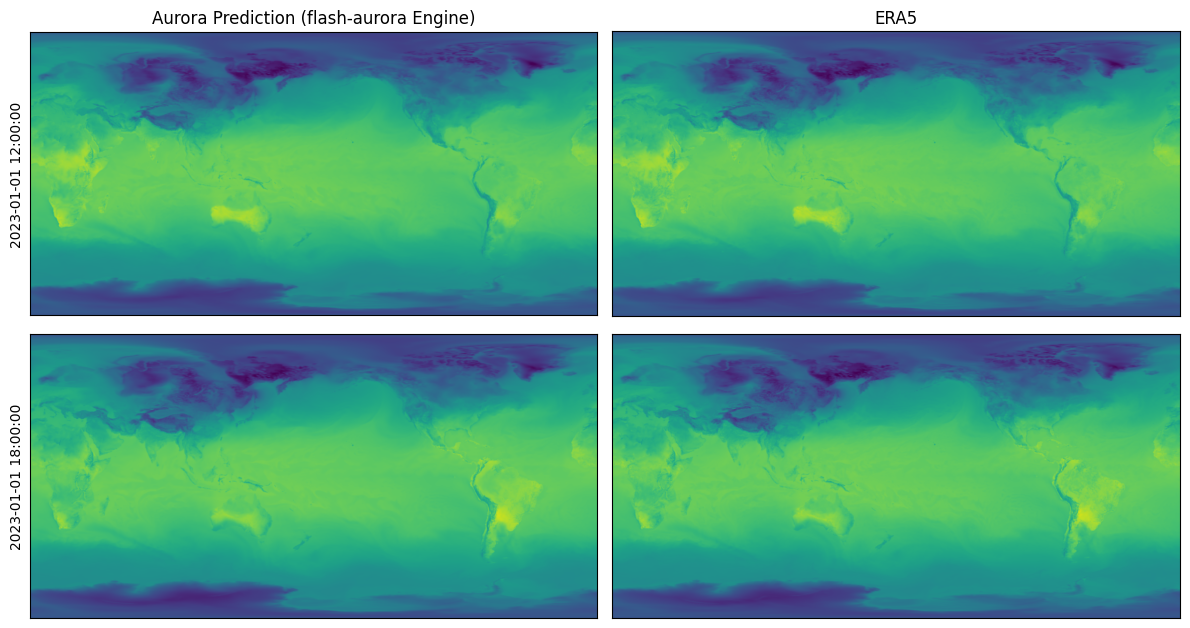

In [5]:
import matplotlib.pyplot as plt
import xarray as xr

surface_path = result.paths["surface"]
surf_vars_ds = xr.open_dataset(surface_path, engine="netcdf4")

fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))

for i in range(ax.shape[0]):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50)
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction (flash-aurora Engine)")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ax[i, 1].imshow(surf_vars_ds["t2m"][2 + i].values - 273.15, vmin=-50, vmax=50)
    if i == 0:
        ax[i, 1].set_title("ERA5")
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

plt.tight_layout()
plt.show()


## 5.（可选）导出预测 NetCDF


In [ ]:
export_dir = Path("/root/autodl-tmp/aurora/output/era5_pretrained")
engine.config.export_dir = export_dir
paths = list(engine.rollout_and_export(batch, steps=ROLLOUT_STEPS))
paths